In [1]:
# This notebook is not related to the project frustrations_eda

In [152]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
from torchvision import datasets
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable

In [133]:
def avg_pool_coarse_grain2d(x: torch.Tensor, kernel_size: int):
    """
    Applies rolling mean to the input tensor using average pooling.
    The output tensor has the same size as the input tensor 
    due to circular padding.
    """
    # Apply circular padding
    padding = kernel_size // 2
    # Create the averaging kernel
    avg_kernel = torch.ones((1, 1, kernel_size, kernel_size)) / (kernel_size ** 2)

    x_padded = F.pad(x, (padding, padding - 1, padding, padding - 1), mode='circular')

    # Apply average pooling
    # result = F.avg_pool2d(x_padded, kernel_size, stride=1, padding=0)

    # Apply convolution with the averaging kernel
    result = F.conv2d(x_padded, avg_kernel, stride=1, padding=0, groups=x.size(1))

    return result

In [134]:
class AvgPoolCoarseGrain2D(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.kernel_size = kernel_size

    def forward(self, x):
        return avg_pool_coarse_grain2d(x, self.kernel_size)

In [144]:
def msc(input_tensor: torch.Tensor, coarse_grainer: Callable):
    """
    Multi-scale complexity of the input tensor.
    """
    scale = 2
    complexities = []
    prev_coarse_grained_tensor = input_tensor
    while scale <= input_tensor.shape[-1]:
        new_coarse_grained_tensor = coarse_grainer(input_tensor, scale)
        complexities.append(
            torch.sum(
                (new_coarse_grained_tensor - prev_coarse_grained_tensor) ** 2,
                dim=(-1, -2),
            )
        )
        prev_coarse_grained_tensor = new_coarse_grained_tensor
        scale *= 2
    return torch.stack(complexities).sum(dim=0)

In [136]:
def get_input_tensors(n):
    # Load a sample image from MNIST dataset for demonstration (grayscale image)
    dataset = datasets.DTD(root=".", download=True)
    input_tensors = []
    for i in range(n):
        sample_image, _ = dataset[np.random.randint(len(dataset))]  # Getting the first sample

        # Convert the image to a PyTorch tensor and add a batch dimension
        input_tensor = ToTensor()(sample_image).mean(dim=0)[:256, :256]
        input_tensors.append(input_tensor)
    return torch.stack(input_tensors).unsqueeze(1)


In [ ]:
# Instantiate the AvgPoolCoarseGrain2D module
#avg_pool_module = AvgPoolCoarseGrain2D(kernel_size)
input_tensor = get_input_tensors(1)


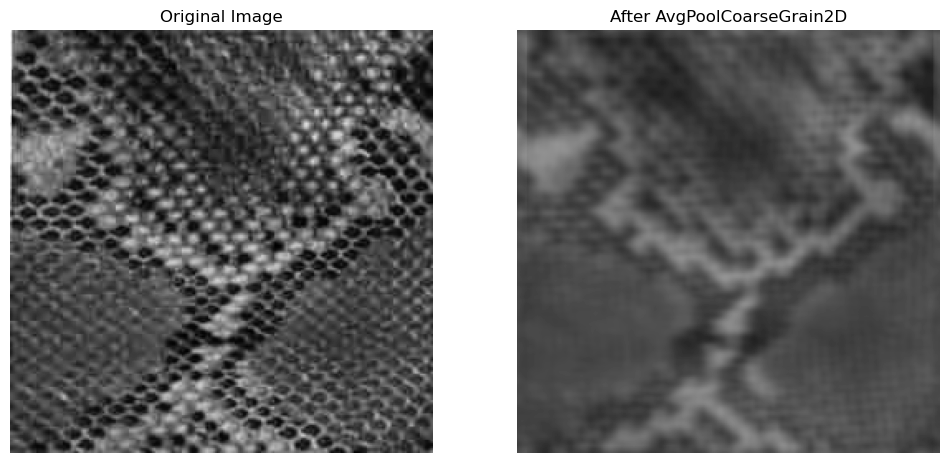

In [169]:
# Define kernel size for the pooling operation
kernel_size = 10

# avg_pool_module =  torchvision.transforms.GaussianBlur(kernel_size=33, sigma=kernel_size // 2)
avg_pool_module = AvgPoolCoarseGrain2D(kernel_size)

# Apply the module to the input tensor
output_tensor = avg_pool_module(input_tensor)

# Convert tensors to numpy arrays for visualization
input_image_np = input_tensor.squeeze().numpy() 
output_image_np = output_tensor.squeeze().numpy()

# Plotting the original and processed images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(input_image_np, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(
    output_image_np,
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title("After AvgPoolCoarseGrain2D")
plt.axis("off")

plt.show()

In [138]:
input_tensor.shape

torch.Size([1, 1, 256, 256])

In [139]:
get_input_tensors(10).shape

torch.Size([10, 1, 256, 256])

In [140]:
avg_pool_coarse_grain2d(get_input_tensors(10), 4).shape

torch.Size([10, 1, 256, 256])

In [145]:
input_tensors = get_input_tensors(50)

In [174]:
mscs = msc(
    input_tensors,
    lambda x, scale: torchvision.transforms.GaussianBlur(
        kernel_size=255, sigma=scale / 2
    )(x),
)

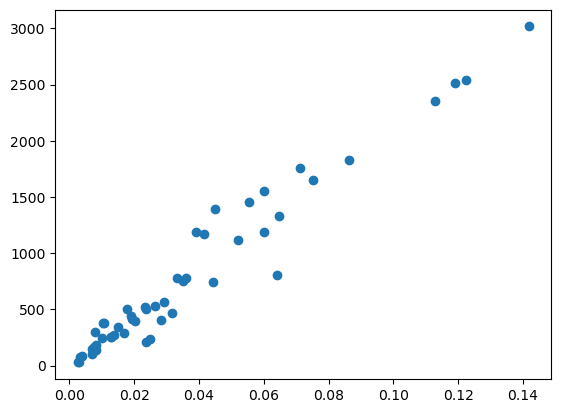

In [175]:
plt.plot(
    input_tensors.var(dim=(-1, -2)).reshape(-1).detach().numpy(),
    mscs.reshape(-1).detach().numpy(),
    "o",
)

In [176]:
np.corrcoef(
    input_tensors.var(dim=(-1, -2)).reshape(-1).detach().numpy(),
    mscs.reshape(-1).detach().numpy(),
)

array([[1.        , 0.97438457],
       [0.97438457, 1.        ]])